# Movie Recommender System
This is one of my machine learning projects for the summer of 2026. Recommender systems are especially intersting to me beacuase they power so many of the most important digital platforms (Instagram, Spotify, movie streaming services, Youtube, etc). I learned about them in my last semester at Tufts, and this is my first attempt at working with them. I was between making one for movies and music before ultimatley choosing movies; I feel like the data is a little easier to work with and less subjective.

I plan to try both content-based recommenders and collaborative filtering. I also want to try and make a system where instead of giving recommendations based on one movie, a user can put in TWO movies and get a list of other recommended films that are similar to the two of these (like a movie blender).

The following cells are just setting everything up for later work; importing data, cleaning data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ast import literal_eval
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
!pip install surprise
from surprise import Dataset, SVD, Reader
from surprise.model_selection.search import GridSearchCV
from surprise.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
movies_path = "/content/drive/MyDrive/movie_data/movies_metadata.csv"
ratings_path = "/content/drive/MyDrive/movie_data/ratings.csv"
credits_path = "/content/drive/MyDrive/movie_data/credits.csv"
keywords_path = "/content/drive/MyDrive/movie_data/keywords.csv"
links_path = "/content/drive/MyDrive/movie_data/links.csv"
small_ratings_path = "/content/drive/MyDrive/movie_data/ratings_small.csv"

In [ ]:
movie_df = pd.read_csv(movies_path)
rating_df = pd.read_csv(ratings_path)
credit_df = pd.read_csv(credits_path)
keyword_df = pd.read_csv(keywords_path)
links_df = pd.read_csv(links_path)
small_rating_df = pd.read_csv(small_ratings_path)

/tmp/ipykernel_2169/2484106091.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movie_df = pd.read_csv(movies_path)


# DATA CLEANING
Annoying but necessary step is cleaning the data and getting it prepped for use. The following section is going to have all my work for getting everything formatted correctly. I won't be leaving detailed notes on this section, but will summarize at the end.

In [ ]:
with pd.option_context('display.max_columns', None):
  display("movie dataframe:", movie_df.head())
print(movie_df.dtypes)


'movie dataframe:'

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object


In [ ]:
missing_by_column = movie_df.isnull().sum()
print(missing_by_column[missing_by_column > 0])
# Drop cols with many missing (and poster path because that's useless)
movie_df = movie_df.drop(['belongs_to_collection', 'homepage', 'tagline', 'poster_path'], axis=1)

belongs_to_collection    40972
homepage                 37684
imdb_id                     17
original_language           11
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64


In [ ]:
# Extract genres, production companies, countries, and spoken languages
movie_df['genres'] = movie_df['genres'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
movie_df['production_companies'] = movie_df['production_companies'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
movie_df['production_countries'] = movie_df['production_countries'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
movie_df['spoken_languages'] = movie_df['spoken_languages'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [ ]:
display(movie_df.loc[:, ['genres', 'production_companies', 'production_countries', 'spoken_languages']])

,genres,production_companies,production_countries,spoken_languages
0,"[Animation, Comedy, Family]",[Pixar Animation Studios],[United States of America],[English]
1,"[Adventure, Fantasy, Family]","[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],"[English, Français]"
2,"[Romance, Comedy]","[Warner Bros., Lancaster Gate]",[United States of America],[English]
3,"[Comedy, Drama, Romance]",[Twentieth Century Fox Film Corporation],[United States of America],[English]
4,[Comedy],"[Sandollar Productions, Touchstone Pictures]",[United States of America],[English]
...,...,...,...,...
45461,"[Drama, Family]",[],[Iran],[فارسی]
45462,[Drama],[Sine Olivia],[Philippines],[]
45463,"[Action, Drama, Thriller]",[American World Pictures],[United States of America],[English]
45464,[],[Yermoliev],[Russia],[]


In [ ]:
movie_df['release_date'] = pd.to_datetime(movie_df['release_date'], errors='coerce')
movie_df['year'] = movie_df['release_date'].dt.year
# Fill missing years with average (1992)
movie_df['year'] = movie_df['year'].fillna(round(movie_df['year'].astype('float').mean()))
#drop rest of release date
movie_df = movie_df.drop('release_date', axis=1)

In [ ]:
# Fill missing values in runtime with the average
movie_df['runtime'] = movie_df['runtime'].fillna(movie_df['runtime'].astype('float').mean())

In [ ]:
missing_by_column = movie_df.isnull().sum()
print(missing_by_column[missing_by_column > 0])

imdb_id               17
original_language     11
overview             954
popularity             5
revenue                6
status                87
title                  6
video                  6
vote_average           6
vote_count             6
dtype: int64


In [ ]:
# Drop rows with missing title and missing imdb_id (probably not significant films)
movie_df = movie_df.dropna(subset=['title','imdb_id','original_language','status'])

In [ ]:
missing_by_column = movie_df.isnull().sum()
print(missing_by_column[missing_by_column > 0])

overview    935
dtype: int64


In [ ]:
def movie_title_from_id(id):
  movie_index = movie_df.index[movie_df['id'] == str(id)]
  movie_title = movie_df.loc[movie_index, 'title'].iloc[0]
  return movie_title

def movie_id_from_title(title):
  movie_index = movie_df.index[movie_df['title'] == title]
  movie_id = movie_df.loc[movie_index, 'id'].iloc[0]
  return movie_id

In [ ]:
print(movie_title_from_id(862))
print(movie_id_from_title('Toy Story'))

Toy Story
862


**Overview of cleaning for movie dataframe:** \
Extracted genre, production company, production country, and spoken languages from dicts. Turned release date into just release year and filled missing values with the average release year. Also filled missing runtime values with average runtime. Dropped rows with missing title, imdb id, original language, or status because these are likely not significant movies, and there weren't many of them to lose. \
What remains of missing values are some movies with no overview, but that's it.  \
Also added function that gives you the name of a movie based on its id.

In [ ]:
display(credit_df.head())
print(credit_df.iloc[0]['cast'])
print(credit_df.iloc[0]['crew'])

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


[{'cast_id': 14, 'character': 'Woody (voice)', 'credit_id': '52fe4284c3a36847f8024f95', 'gender': 2, 'id': 31, 'name': 'Tom Hanks', 'order': 0, 'profile_path': '/pQFoyx7rp09CJTAb932F2g8Nlho.jpg'}, {'cast_id': 15, 'character': 'Buzz Lightyear (voice)', 'credit_id': '52fe4284c3a36847f8024f99', 'gender': 2, 'id': 12898, 'name': 'Tim Allen', 'order': 1, 'profile_path': '/uX2xVf6pMmPepxnvFWyBtjexzgY.jpg'}, {'cast_id': 16, 'character': 'Mr. Potato Head (voice)', 'credit_id': '52fe4284c3a36847f8024f9d', 'gender': 2, 'id': 7167, 'name': 'Don Rickles', 'order': 2, 'profile_path': '/h5BcaDMPRVLHLDzbQavec4xfSdt.jpg'}, {'cast_id': 17, 'character': 'Slinky Dog (voice)', 'credit_id': '52fe4284c3a36847f8024fa1', 'gender': 2, 'id': 12899, 'name': 'Jim Varney', 'order': 3, 'profile_path': '/eIo2jVVXYgjDtaHoF19Ll9vtW7h.jpg'}, {'cast_id': 18, 'character': 'Rex (voice)', 'credit_id': '52fe4284c3a36847f8024fa5', 'gender': 2, 'id': 12900, 'name': 'Wallace Shawn', 'order': 4, 'profile_path': '/oGE6JqPP2xH4tN

In [ ]:
credit_df['cast'] = credit_df['cast'].apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [ ]:
print(credit_df.iloc[0]['cast'])

['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim Varney', 'Wallace Shawn', 'John Ratzenberger', 'Annie Potts', 'John Morris', 'Erik von Detten', 'Laurie Metcalf', 'R. Lee Ermey', 'Sarah Freeman', 'Penn Jillette']


In [ ]:
credit_df['director'] = credit_df['crew'].apply(literal_eval).apply(lambda x: next((i['name'] for i in x if i['job'] == 'Director'), np.nan))

In [ ]:
print(credit_df.iloc[0:5]['director'])

0      John Lasseter
1       Joe Johnston
2      Howard Deutch
3    Forest Whitaker
4      Charles Shyer
Name: director, dtype: object


In [ ]:
credit_df['writers'] = credit_df['crew'].apply(literal_eval).apply(lambda x: [i['name'] for i in x if i['job'] == 'Screenplay'])

In [ ]:
print(credit_df.iloc[0:5]['writers'])

0    [Joss Whedon, Andrew Stanton, Joel Cohen, Alec...
1        [Jonathan Hensleigh, Greg Taylor, Jim Strain]
2                                                   []
3                        [Ronald Bass, Terry McMillan]
4                       [Nancy Meyers, Albert Hackett]
Name: writers, dtype: object


In [ ]:
credit_df = credit_df.drop('crew', axis=1)

In [ ]:
display(credit_df.head())

,cast,id,director,writers
0,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",862,John Lasseter,"[Joss Whedon, Andrew Stanton, Joel Cohen, Alec..."
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst,...",8844,Joe Johnston,"[Jonathan Hensleigh, Greg Taylor, Jim Strain]"
2,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",15602,Howard Deutch,[]
3,"[Whitney Houston, Angela Bassett, Loretta Devi...",31357,Forest Whitaker,"[Ronald Bass, Terry McMillan]"
4,"[Steve Martin, Diane Keaton, Martin Short, Kim...",11862,Charles Shyer,"[Nancy Meyers, Albert Hackett]"


In [ ]:
missing_by_column = credit_df.isnull().sum()
print(missing_by_column[missing_by_column > 0])

director    887
dtype: int64


**Overview of cleaning for cast/crew dataframe:** \
Extracted the cast from dicts. Also extracted directior and screenwriters from the crew dict for each movie, but only those roles. Other members of the crew (composer, cinematopgrapher, etc) do contribute to the vibe of a film but not nearly as much as the director/writing team. Some films are missing director (and probably some have empty cast/writer list) but not many, so we say it's ok.

In [ ]:
display(keyword_df.head())
print(keyword_df.iloc[0]['keywords'])

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'friendship'}, {'id': 9713, 'name': 'friends'}, {'id': 9823, 'name': 'rivalry'}, {'id': 165503, 'name': 'boy next door'}, {'id': 170722, 'name': 'new toy'}, {'id': 187065, 'name': 'toy comes to life'}]


In [ ]:
keyword_df['keywords'] = keyword_df['keywords'].apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [ ]:
print(keyword_df.iloc[0:5]['keywords'])

0    [jealousy, toy, boy, friendship, friends, riva...
1    [board game, disappearance, based on children'...
2    [fishing, best friend, duringcreditsstinger, o...
3    [based on novel, interracial relationship, sin...
4    [baby, midlife crisis, confidence, aging, daug...
Name: keywords, dtype: object


# **Content-Based Recommender**
The first recommendtion system I'm going to try making is a content-based recommender using the features from the cleaned datasets above. I'm going to pick features that contribute significantly to the overall vibe of the movie and ignore those that, while they may be slightly helpful, are really not all that important. Based on this, I'm going to use the genres, cast, director, writers, keywords, production companies, year, popularity, runtime, and vote average.

The genre, cast, director, writers, keywords, and production companies are all categorical variables and will need to be handled, possibly with a count vectorizer to find other movies with overlap. The other variables are numeric and can be left alone, although they should be scaled so that they're all similar in value.

Before we do anything though, we need to make it so the names are unique in the vectorizer, by removing spaces and capitalization. Otherwise, model would think Tom Hanks and Tom Hardy are similar.

In [ ]:
def fix_names(x):
  for i in range(len(x)):
    x[i] = x[i].lower()
    x[i] = x[i].replace(" ", "")
  return x

credit_df['cast_fixed'] = credit_df['cast'].apply(fix_names)
credit_df['writers_fixed'] = credit_df['writers'].apply(fix_names)
credit_df['director_fixed'] = credit_df['director'].str.lower().str.replace(" ", "")

In [ ]:
print(credit_df.iloc[0:5]['director_fixed'])

0      johnlasseter
1       joejohnston
2      howarddeutch
3    forestwhitaker
4      charlesshyer
Name: director_fixed, dtype: object


Same thing has to be done to the production companies.

In [ ]:
movie_df['production_companies_fixed'] = movie_df['production_companies'].apply(fix_names)

In [ ]:
print(movie_df.iloc[0:5]['production_companies_fixed'])

0                              [pixaranimationstudios]
1    [tristarpictures, teitlerfilm, interscopecommu...
2                         [warnerbros., lancastergate]
3                 [twentiethcenturyfoxfilmcorporation]
4           [sandollarproductions, touchstonepictures]
Name: production_companies_fixed, dtype: object


I will NOT be removing spaces on the keywords since some longer keywords may contain words that match with other similar keywords. For example, "based on novel" and "based on children's book" will both have the words "based on" in them, which is helpful.  

Next step is to combine all of the relevant features into a combined dataframe.

In [ ]:
credit_df['id'] = credit_df['id'].astype(str)
movie_df['id'] = movie_df['id'].astype(str)
keyword_df['id'] = keyword_df['id'].astype(str)

cdf = pd.merge(credit_df.loc[:,['cast_fixed', 'writers_fixed', 'director_fixed', 'id']], movie_df.loc[:, ['title', 'genres', 'production_companies_fixed', 'runtime', 'id', 'year', 'popularity', 'vote_average', 'vote_count']], on='id', how='inner')
cdf = pd.merge(cdf, keyword_df.loc[:, ['keywords', 'id']], on='id', how='inner')

In [ ]:
# The film "Force Majeur" is duplicated at these indices for some reason
cdf = cdf.drop(index=[24260, 24261, 24262, 46311, 46312, 46313, 46314])

In [ ]:
display(cdf.head())

,cast_fixed,writers_fixed,director_fixed,id,title,genres,production_companies_fixed,runtime,year,popularity,vote_average,vote_count,keywords
0,"[tomhanks, timallen, donrickles, jimvarney, wa...","[josswhedon, andrewstanton, joelcohen, alecsok...",johnlasseter,862,Toy Story,"[Animation, Comedy, Family]",[pixaranimationstudios],81.0,1995.0,21.946943,7.7,5415.0,"[jealousy, toy, boy, friendship, friends, riva..."
1,"[robinwilliams, jonathanhyde, kirstendunst, br...","[jonathanhensleigh, gregtaylor, jimstrain]",joejohnston,8844,Jumanji,"[Adventure, Fantasy, Family]","[tristarpictures, teitlerfilm, interscopecommu...",104.0,1995.0,17.015539,6.9,2413.0,"[board game, disappearance, based on children'..."
2,"[waltermatthau, jacklemmon, ann-margret, sophi...",[],howarddeutch,15602,Grumpier Old Men,"[Romance, Comedy]","[warnerbros., lancastergate]",101.0,1995.0,11.7129,6.5,92.0,"[fishing, best friend, duringcreditsstinger, o..."
3,"[whitneyhouston, angelabassett, lorettadevine,...","[ronaldbass, terrymcmillan]",forestwhitaker,31357,Waiting to Exhale,"[Comedy, Drama, Romance]",[twentiethcenturyfoxfilmcorporation],127.0,1995.0,3.859495,6.1,34.0,"[based on novel, interracial relationship, sin..."
4,"[stevemartin, dianekeaton, martinshort, kimber...","[nancymeyers, alberthackett]",charlesshyer,11862,Father of the Bride Part II,[Comedy],"[sandollarproductions, touchstonepictures]",106.0,1995.0,8.387519,5.7,173.0,"[baby, midlife crisis, confidence, aging, daug..."


Just a note: I added the vote_count into the combined dataframe in case we need to trim away movies that aren't popular enough. The following function removes any films that are below the nth percentile of popularity.

In [ ]:
def filter_by_vote_count_percentile(df, n):
  """
  Filters a DataFrame to keep rows where 'vote_count' is greater than the nth percentile.

  Args:
    df (pd.DataFrame): The input DataFrame containing a 'vote_count' column.
    n (int): The percentile to use for filtering (e.g., 80 for 80th percentile).

  Returns:
    pd.DataFrame: A new DataFrame with rows filtered based on vote_count.
  """
  if 'vote_count' not in df.columns:
    raise ValueError("DataFrame must contain a 'vote_count' column.")

  if not (0 <= n <= 100):
    raise ValueError("Percentile 'n' must be between 0 and 100.")

  # Calculate the nth percentile of vote_count
  vote_count_threshold = df['vote_count'].quantile(n / 100)

  # Filter the DataFrame
  filtered_df = df[df['vote_count'] > vote_count_threshold]

  return filtered_df

To start with, remove the bottom 50% of popularity movies, to eliminate any outliar data points.

In [ ]:
cdf_50 = filter_by_vote_count_percentile(cdf, 50)
cdf_50 = cdf_50.reset_index(drop=True)

Next step is to combine all of our text data into a soup for the count vectorizer to get all the counts in one pass. Going to add three instances of director and two instances of the first two actors, as these people are especially important.

In [ ]:
def soupify(x):
  'Returns a string of the soupified version of the row of the combined dataframe.'
  soup = ""
  for i in range(len(x['cast_fixed'])):
    soup += x['cast_fixed'][i] + " "
    if i < 2:
      soup += x['cast_fixed'][i] + " "
    # Only take the first 5 people on the cast list
    if i == 5:
      break

  if pd.isna(x['director_fixed']) == False:
    for i in range(3):
      soup += x['director_fixed'] + " "

  for i in range(len(x['writers_fixed'])):
    soup += x['writers_fixed'][i] + " "

  for i in range(len(x['production_companies_fixed'])):
    soup += x['production_companies_fixed'][i] + " "

  for i in range(len(x['keywords'])):
    soup += x['keywords'][i] + " "

  for i in range(len(x['genres'])):
    soup += x['genres'][i] + " "

  return soup

In [ ]:
cdf_50['soup'] = cdf_50.apply(soupify, axis=1)

In [ ]:
print(cdf_50.loc[0, 'soup'])

tomhanks tomhanks timallen timallen donrickles jimvarney wallaceshawn johnratzenberger johnlasseter johnlasseter johnlasseter josswhedon andrewstanton joelcohen alecsokolow pixaranimationstudios jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life Animation Comedy Family 


The soup has been cooked! Next step is to use the count vectorizer to make matrix, and use cosine similarity to determine which movies are most similar based on the matrix.

In [ ]:
cv = CountVectorizer(stop_words='english', token_pattern=r"(?u)\S+")
count_matrix = cv.fit_transform(cdf_50['soup'])

In [ ]:
cosine_sim = cosine_similarity(count_matrix)

We now have a similarity value for all movies to all other movies!! First thing's first, write a function that takes in a movie title and gives back the top n matches. We have to first get the index in the matrix from the title, and then use this index on the cosine_sim matrix to find the similar films. This will give more indices, which we'll have to turn back into titles. I'm making functions to make this index-to-title switching process more convenient.

In [ ]:
def index_from_title(movie_title):
  return cdf_50[cdf_50['title'] == movie_title].index.values[0]
def title_from_index(i):
  return cdf_50.iloc[i]['title']

In [ ]:
def top_matches(movie, n):
  "Returns the top n matches for a given movie"
  movie_index = index_from_title(movie)
  sims = cosine_sim[movie_index]
  sims = list(enumerate(sims))
  sims = sorted(sims, key=lambda x: x[1], reverse=True)
  sims = sims[1:n+1]
  for i in range(len(sims)):
    sims[i] = (title_from_index(sims[i][0]))
  return sims

In [ ]:
top_10 = top_matches('Toy Story', 10)
for i in range(len(top_10)):
  print(top_10[i])

Toy Story 2
Toy Story That Time Forgot
Toy Story 3
Tin Toy
Red's Dream
Knick Knack
Luxo Jr.
Toy Story of Terror!
Partysaurus Rex
A Bug's Life


The predictions are good in the sense that these are all very similar to toy story, but a majority of these are Pixar animated shorts, NOT films. We can use the other numerical features that we haven't used yet (year, popularity, rating, and runtime) to make the recomendations better.

We can use this current recommender to create a list of similar films and then sort that list based on how similar the numeric parts are (based on euclidean distance). Hopefully then if we put in a feature length animated film, we'll get back out a feature length animated film.

First, scale all the numeric columns with minmax scaler so that the scale of the values doesn't impact its importance.

In [ ]:
cdf_50['popularity'] = pd.to_numeric(cdf_50['popularity'], errors='coerce')
cdf_50['popularity_log'] = np.log1p(cdf_50['popularity'])
cdf_50['runtime'] = pd.to_numeric(cdf_50['runtime'], errors='coerce')
cdf_50['runtime_log'] = np.log1p(cdf_50['runtime'])

num_cols = ['runtime_log', 'year', 'popularity_log', 'vote_average']
scaler = MinMaxScaler()
cdf_50[num_cols] = scaler.fit_transform(cdf_50[num_cols])
cdf_50 = cdf_50.drop('popularity', axis=1)
cdf_50 = cdf_50.drop('runtime', axis=1)
cdf_50.rename(columns={'popularity_log': 'popularity'}, inplace=True)
cdf_50.rename(columns={'runtime_log': 'runtime'}, inplace=True)

In [ ]:
cdf['popularity'] = pd.to_numeric(cdf['popularity'], errors='coerce')
cdf['popularity_log'] = np.log1p(cdf['popularity'])
cdf['runtime'] = pd.to_numeric(cdf['runtime'], errors='coerce')
cdf['runtime_log'] = np.log1p(cdf['runtime'])

In [ ]:
cdf_50.head()

,cast_fixed,writers_fixed,director_fixed,id,title,genres,production_companies_fixed,year,vote_average,vote_count,keywords,soup,popularity,runtime
0,"[tomhanks, timallen, donrickles, jimvarney, wa...","[josswhedon, andrewstanton, joelcohen, alecsok...",johnlasseter,862,Toy Story,"[Animation, Comedy, Family]",[pixaranimationstudios],0.828767,0.810526,5415.0,"[jealousy, toy, boy, friendship, friends, riva...",tomhanks tomhanks timallen timallen donrickles...,0.496766,0.647713
1,"[robinwilliams, jonathanhyde, kirstendunst, br...","[jonathanhensleigh, gregtaylor, jimstrain]",joejohnston,8844,Jumanji,"[Adventure, Fantasy, Family]","[tristarpictures, teitlerfilm, interscopecommu...",0.828767,0.726316,2413.0,"[board game, disappearance, based on children'...",robinwilliams robinwilliams jonathanhyde jonat...,0.458405,0.684053
2,"[waltermatthau, jacklemmon, ann-margret, sophi...",[],howarddeutch,15602,Grumpier Old Men,"[Romance, Comedy]","[warnerbros., lancastergate]",0.828767,0.684211,92.0,"[fishing, best friend, duringcreditsstinger, o...",waltermatthau waltermatthau jacklemmon jacklem...,0.403131,0.679793
3,"[whitneyhouston, angelabassett, lorettadevine,...","[ronaldbass, terrymcmillan]",forestwhitaker,31357,Waiting to Exhale,"[Comedy, Drama, Romance]",[twentiethcenturyfoxfilmcorporation],0.828767,0.642105,34.0,"[based on novel, interracial relationship, sin...",whitneyhouston whitneyhouston angelabassett an...,0.250657,0.713166
4,"[stevemartin, dianekeaton, martinshort, kimber...","[nancymeyers, alberthackett]",charlesshyer,11862,Father of the Bride Part II,[Comedy],"[sandollarproductions, touchstonepictures]",0.828767,0.600000,173.0,"[baby, midlife crisis, confidence, aging, daug...",stevemartin stevemartin dianekeaton dianekeato...,0.355053,0.686827


In [ ]:
from scipy.spatial import distance
def numeric_cols(index):
  num_df = cdf_50.loc[index, ['runtime', 'year', 'popularity', 'vote_average']]
  return num_df

def numeric_similarity(movie, similar_movies):
  movie_index = index_from_title(movie)
  movie_num_cols = numeric_cols(movie_index)

  for i in range(len(similar_movies)):
    comparison_index = index_from_title(similar_movies[i])
    comparison_num_cols = numeric_cols(comparison_index)
    distance = euclidean_distances([movie_num_cols], [comparison_num_cols])
    similar_movies[i] = (similar_movies[i], distance)

  return similar_movies


In [ ]:

top_50 = top_matches('Toy Story', 50)
top_50 = numeric_similarity('Toy Story', top_50)
for i in range(len(top_50)):
  print(top_50[i])

('Toy Story 2', array([[0.06328163]]))
('Toy Story That Time Forgot', array([[0.28261059]]))
('Toy Story 3', array([[0.11572191]]))
('Tin Toy', array([[0.45463045]]))
("Red's Dream", array([[0.503565]]))
('Knick Knack', array([[0.46328146]]))
('Luxo Jr.', array([[0.52065825]]))
('Toy Story of Terror!', array([[0.48767837]]))
('Partysaurus Rex', array([[0.40797427]]))
("A Bug's Life", array([[0.10726852]]))
('Cars 2', array([[0.24194175]]))
('Mater and the Ghostlight', array([[0.41809731]]))
('Cars', array([[0.14984306]]))
('Hawaiian Vacation', array([[0.39957589]]))
('Crazy on the Outside', array([[0.3982433]]))
('Big', array([[0.16076126]]))
('Small Soldiers', array([[0.20197306]]))
('Larry Crowne', array([[0.26130413]]))
('The Pixar Story', array([[0.15230207]]))
('That Thing You Do!', array([[0.17167924]]))
('WALL·E', array([[0.10483525]]))
('Pinocchio', array([[0.39167613]]))
('Small Fry', array([[0.38996388]]))
('Finding Dory', array([[0.18506285]]))
('The Kingdom of Dreams and Ma

We now have the distance for how similar the numeric cols are for each film. If we sort these by the numeric value, then the top few will be the most similar based on both the categorical and numeric columns. This means that a feature length film that was popular and well received will be more similar to other popular feature length films, on top of the patterns already found by the cast/crew/genre similarity we found earlier.

In [ ]:
def sort_movies(movies):
  "Sorts movies by numeric similarity"
  sorted_movies = sorted(movies, key=lambda x: x[1])
  return sorted_movies

def n_most_similar(movie_title, n):
  top_200 = top_matches(movie_title, 200)
  top_200 = numeric_similarity(movie_title, top_200)
  top_200 = sort_movies(top_200)
  return [movie[0] for movie in top_200[:n]]


In [ ]:
display(n_most_similar('Toy Story', 10))

['Monsters, Inc.',
 'Aladdin',
 'Toy Story 2',
 'Finding Nemo',
 'Spirit: Stallion of the Cimarron',
 'Ratatouille',
 'Philadelphia',
 'Up',
 'WALL·E',
 'Galaxy Quest']

This is an excellent result!! All popular feature length films, with clear reasons for each of them being selected. Galaxy Quest being there is pretty interesting because it's not animated, but I'm guessing the tags were similar enough (and Tim Allen stars, so there's a big plus there). Going to test a few more movies below:

In [ ]:
display(n_most_similar('Interstellar', 10))

['Inception',
 'The Martian',
 'Rogue One: A Star Wars Story',
 'The Dark Knight Rises',
 'Guardians of the Galaxy',
 'Batman Begins',
 'Gladiator',
 'Hidden Figures',
 'The Prestige',
 'Two Is a Family']

Obvious space/christopher nolan connection, but what the heck is "Two is a Family" doing on there? Weird..

In [ ]:
display(n_most_similar('Mean Girls', 10))

['Napoleon Dynamite',
 'Superbad',
 'Wild Child',
 '21 Jump Street',
 'Easy A',
 'Just Like Heaven',
 'Clueless',
 'The Girl Next Door',
 'Dirty Girl',
 'The Spiderwick Chronicles']

I actually really like the recomendations (helps that Napolean Dynamite is one of my favorite movies ever) but they got the vibe pretty accurately.

**FINAL NOTES FOR CONTENT-BASED APPROACH**

Overall, I am very pleased with how this first recommender works based on the severly limited data that we gave it. We didn't even use the overview section! A brief summary of the entire pipeline/process is below:

- Cleaned all the data and formatted the text correctly, making it usable.
- Combined all relevant text data into one long string, creating copies of important info. The string is as follows:
  - Top five actors (with the first two listed being included twice)
  - Director (included three times)
  - Writers
  - Production Companies
  - Keywords (tags basically)
  - Genres
- Eliminated irrelevent movies (films under the 50th percentile of review_count).
- Turned each movie's string into a vector using a count vectorizer.
- Calculated similarity between each vector based on cosine similarity.
- Wrote a function to get the n most similar films to a given film.
- Calculated the similarity between each film's remaining numeric features:
  - Release year
  - Popularity
  - Runtime
  - Score
- Used the numeric similarity to sort the top 200 similar films, with the FINAL RECOMENDATION being the top n values of this sort.

Clean up some memory for the next section:

In [ ]:
del count_matrix, cv, cosine_sim, cdf

# **Collaborative Filtering**
For this section I am going to use the latent-factor method of collaborative filtering. This method assigns each movie and user to an embedding vector of size K, with these K being the latent factors. Stack up all of the users and the movies to create 2 matrices. Multiplying these matrices together gives one value for each movie/user pair, with this value being the user's predicted rating for the movie. Training for this method looks like selecting random values at first and then changing the latent factors accordingly repeatedly to match the actual ratings.

Instead of implementing this from scratch, I plan on using the Surprise library's SVD implementation to save time. First get the df formatted correctly for reading.

In [ ]:
display(rating_df.head())
print(rating_df.shape)

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


(26024289, 4)


In [ ]:
rating_df = rating_df.drop('timestamp', axis=1)
small_rating_df = small_rating_df.drop('timestamp', axis=1)

In [ ]:
rating_df = rating_df.iloc[0:5000000]

In [ ]:
display(rating_df['rating'].min())
display(rating_df['rating'].max())
print(rating_df.shape)

0.5

5.0

(5000000, 3)


BEFORE READING IN DATA: The movie df from above uses TMDB ids, so I'm going to switch all IDs in this df to match.

In [ ]:
print(links_df.head())

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [ ]:
# build the mapping as a series
tmdb_map = links_df.set_index('movieId')['tmdbId']

# map all at once — vectorized, no loop
rating_df['movieId'] = rating_df['movieId'].map(tmdb_map)
small_rating_df['movieId'] = small_rating_df['movieId'].map(tmdb_map)

# drop unmapped rows and cast
rating_df.dropna(subset=['movieId'], inplace=True)
small_rating_df.dropna(subset=['movieId'], inplace=True)
rating_df['movieId'] = rating_df['movieId'].astype(int)
small_rating_df['movieId'] = small_rating_df['movieId'].astype(int)

In [ ]:
display(rating_df.head())

,userId,movieId,rating
0,1,197,1.0
1,1,10474,4.5
2,1,238,5.0
3,1,240,5.0
4,1,207,5.0


Read in the ratings data

In [ ]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(rating_df, reader)
small_data = Dataset.load_from_df(small_rating_df, reader)

Now we're going to train/evaluate the model. I'm going to do a grid search over some variations of hyperparams to start, before honing in on the best hyperparam combination.

In [ ]:
params = {
    'n_factors': [50, 100, 150],
    'n_epochs': [10, 20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=3, joblib_verbose=3)
grid.fit(small_data)

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:   32.3s
[Parallel(n_jobs=1)]: Done  81 out of  81 | elapsed:  1.7min finished


In [ ]:
display(grid.best_score)
display(grid.best_params)

{'rmse': np.float64(0.8987448407649384), 'mae': np.float64(0.6926600533999135)}

{'rmse': {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'random_state': 0},
 'mae': {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'random_state': 0}}

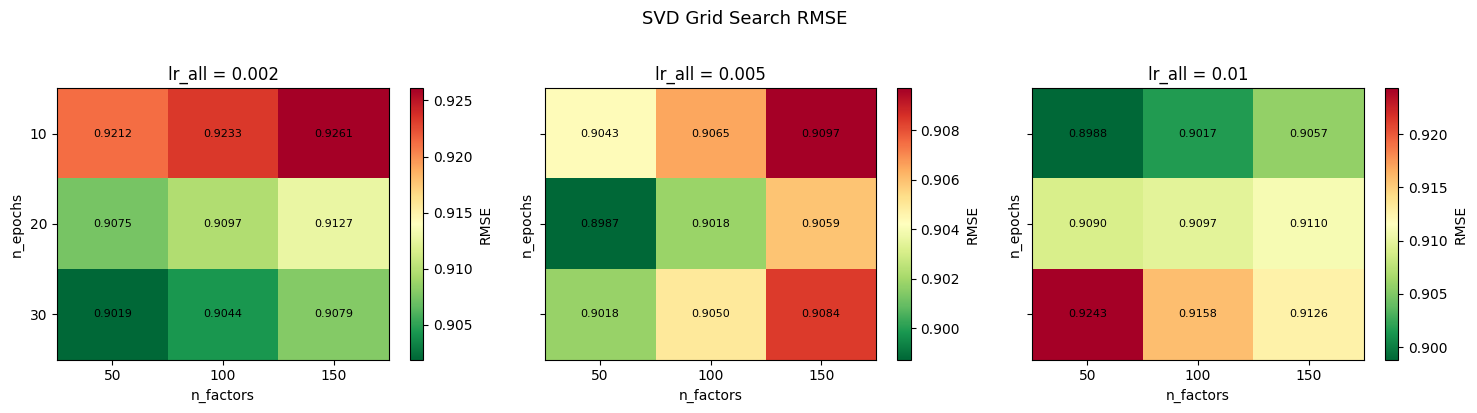

Best RMSE: 0.8987
Best params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'random_state': 0}


In [ ]:
results = pd.DataFrame(grid.cv_results)

n_factors_vals = [50, 100, 150]
n_epochs_vals = [10, 20, 30]
lr_vals = [0.002, 0.005, 0.01]

fig, axes = plt.subplots(1, len(lr_vals), figsize=(15, 4), sharey=True)

for ax, lr in zip(axes, lr_vals):
    # filter to this lr_all value
    mask = results['param_lr_all'] == lr
    subset = results[mask]

    # build the 2D grid
    matrix = np.zeros((len(n_epochs_vals), len(n_factors_vals)))
    for i, epoch in enumerate(n_epochs_vals):
        for j, factor in enumerate(n_factors_vals):
            row = subset[
                (subset['param_n_epochs'] == epoch) &
                (subset['param_n_factors'] == factor)
            ]
            matrix[i, j] = row['mean_test_rmse'].values[0]

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(n_factors_vals)))
    ax.set_xticklabels(n_factors_vals)
    ax.set_yticks(range(len(n_epochs_vals)))
    ax.set_yticklabels(n_epochs_vals)
    ax.set_xlabel('n_factors')
    ax.set_ylabel('n_epochs')
    ax.set_title(f'lr_all = {lr}')

    # annotate each cell with its score
    for i in range(len(n_epochs_vals)):
        for j in range(len(n_factors_vals)):
            ax.text(j, i, f'{matrix[i, j]:.4f}', ha='center', va='center', fontsize=8)

    plt.colorbar(im, ax=ax, label='RMSE')

plt.suptitle('SVD Grid Search RMSE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# also print best combo for reference
print(f"Best RMSE: {grid.best_score['rmse']:.4f}")
print(f"Best params: {grid.best_params['rmse']}")

Ok, pretty good, let's try with lower n_factors since the best option was the lowest. Also going to try adding regularization. Lower LR seems better in general, but LR results are varying wildly so I'm only using a couple of values here.

In [ ]:
params = {
    'n_factors': [25, 40, 50],
    'n_epochs': [10, 20, 30],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.05, 0.1],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=3, joblib_verbose=3)
grid.fit(small_data)

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:   23.4s


In [ ]:
display(grid.best_score)
display(grid.best_params)

In [ ]:
results = pd.DataFrame(grid.cv_results)

n_factors_vals = [25, 40, 50]
n_epochs_vals = [10, 20, 30]
lr_vals = [0.002, 0.005]
reg_vals = [0.02, 0.05, 0.1]

vmin = results['mean_test_rmse'].min()
vmax = results['mean_test_rmse'].max()

# reserve space on the right for the colorbar
fig, axes = plt.subplots(len(lr_vals), len(reg_vals), figsize=(15, 8), sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.2)

for i, lr in enumerate(lr_vals):
    for j, reg in enumerate(reg_vals):
        ax = axes[i, j]

        mask = (results['param_lr_all'] == lr) & (results['param_reg_all'] == reg)
        subset = results[mask]

        matrix = np.zeros((len(n_epochs_vals), len(n_factors_vals)))
        for ei, epoch in enumerate(n_epochs_vals):
            for fi, factor in enumerate(n_factors_vals):
                row = subset[
                    (subset['param_n_epochs'] == epoch) &
                    (subset['param_n_factors'] == factor)
                ]
                matrix[ei, fi] = row['mean_test_rmse'].values[0]

        im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto', vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(n_factors_vals)))
        ax.set_xticklabels(n_factors_vals)
        ax.set_yticks(range(len(n_epochs_vals)))
        ax.set_yticklabels(n_epochs_vals)
        ax.set_title(f'lr_all={lr}, reg_all={reg}', fontsize=9)

        if j == 0:
            ax.set_ylabel('n_epochs')
        if i == len(lr_vals) - 1:
            ax.set_xlabel('n_factors')

        for ei in range(len(n_epochs_vals)):
            for fi in range(len(n_factors_vals)):
                ax.text(fi, ei, f'{matrix[ei, fi]:.4f}',
                        ha='center', va='center', fontsize=7)

# dedicated colorbar axes, outside the subplots
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='RMSE')

plt.suptitle('SVD Grid Search RMSE', fontsize=13)
plt.show()

It looks like if we have higher regularization, we can benefit from more epochs. Let's try that out. Also, learning rate being 0.005 seems sufficient.

In [ ]:
params = {
    'n_factors': [25, 40, 50],
    'n_epochs': [30, 40, 50],
    'lr_all': [0.005],
    'reg_all': [0.05, 0.1, 0.15],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=3, joblib_verbose=3)
grid.fit(small_data)

In [ ]:
display(grid.best_score)
display(grid.best_params)

In [ ]:
results = pd.DataFrame(grid.cv_results)

n_factors_vals = [25, 40, 50]
n_epochs_vals = [30, 40, 50]
reg_vals = [0.05, 0.1, 0.15]

vmin = results['mean_test_rmse'].min()
vmax = results['mean_test_rmse'].max()

fig, axes = plt.subplots(1, len(reg_vals), figsize=(14, 4), sharey=True)
fig.subplots_adjust(right=0.88)

for j, reg in enumerate(reg_vals):
    ax = axes[j]

    mask = results['param_reg_all'] == reg
    subset = results[mask]

    matrix = np.zeros((len(n_epochs_vals), len(n_factors_vals)))
    for ei, epoch in enumerate(n_epochs_vals):
        for fi, factor in enumerate(n_factors_vals):
            row = subset[
                (subset['param_n_epochs'] == epoch) &
                (subset['param_n_factors'] == factor)
            ]
            matrix[ei, fi] = row['mean_test_rmse'].values[0]

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto', vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(n_factors_vals)))
    ax.set_xticklabels(n_factors_vals)
    ax.set_yticks(range(len(n_epochs_vals)))
    ax.set_yticklabels(n_epochs_vals)
    ax.set_title(f'lr_all=0.005, reg_all={reg}', fontsize=9)
    ax.set_xlabel('n_factors')

    if j == 0:
        ax.set_ylabel('n_epochs')

    for ei in range(len(n_epochs_vals)):
        for fi in range(len(n_factors_vals)):
            ax.text(fi, ei, f'{matrix[ei, fi]:.4f}',
                    ha='center', va='center', fontsize=8)

cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='RMSE')

plt.suptitle('SVD Grid Search RMSE', fontsize=13)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


More epochs! Fix all the other values.

In [ ]:
params = {
    'n_factors': [50],
    'n_epochs': [50, 100, 200],
    'lr_all': [0.005],
    'reg_all': [0.1],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=3, joblib_verbose=3)
grid.fit(small_data)

In [ ]:
display(grid.best_score)
display(grid.best_params)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = pd.DataFrame(grid.cv_results)

# auto-read from params — just rerun this cell after each grid search
n_epochs_vals = sorted(params['n_epochs'])
fixed_label = (f"n_factors={params['n_factors'][0]}, "
               f"lr_all={params['lr_all'][0]}, "
               f"reg_all={params['reg_all'][0]}")

vmin = results['mean_test_rmse'].min()
vmax = results['mean_test_rmse'].max()

# single-column matrix (one row per n_epochs)
matrix = np.zeros((len(n_epochs_vals), 1))
for ei, epoch in enumerate(n_epochs_vals):
    row = results[results['param_n_epochs'] == epoch]
    matrix[ei, 0] = row['mean_test_rmse'].values[0]

fig, ax = plt.subplots(figsize=(4, len(n_epochs_vals) * 1.2))

im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto', vmin=vmin, vmax=vmax)

ax.set_xticks([])
ax.set_yticks(range(len(n_epochs_vals)))
ax.set_yticklabels(n_epochs_vals)
ax.set_ylabel('n_epochs')
ax.set_title(f'SVD Grid Search RMSE\n({fixed_label})', fontsize=9)

for ei in range(len(n_epochs_vals)):
    ax.text(0, ei, f'{matrix[ei, 0]:.4f}',
            ha='center', va='center', fontsize=10)

fig.colorbar(im, ax=ax, label='RMSE', shrink=0.6)

plt.tight_layout()
plt.show()

print(f"Best RMSE: {grid.best_score['rmse']:.4f}")
print(f"Best params: {grid.best_params['rmse']}")

Alright! It seems a near-optimal list of hyper-parameters has been found. Let's make a final model with these params and test it out.

In [ ]:
model = SVD(n_factors=50, n_epochs=100, lr_all=0.005, reg_all=0.1, random_state=0)

trainset = data.build_full_trainset()
model.fit(trainset)

In [ ]:
inner_iid = trainset.to_inner_iid(862)
print(inner_iid)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_movies_by_embedding(outer_movie_id, n=10):
  """
  Returns the top N outer movie IDs with the most similar embeddings
  to the given outer_movie_id.
  """
  try:
    # Convert outer movie ID to inner ID for the Surprise model
    inner_iid = trainset.to_inner_iid(outer_movie_id)
  except ValueError:
    return f"Movie with outer ID {outer_movie_id} not found in the training data."

  # Get the embedding vector for the input movie
  input_embedding = model.qi[inner_iid]

  similarities = []
  # Iterate through all inner movie IDs in the trainset
  for other_inner_iid in trainset.all_items():
    if other_inner_iid == inner_iid:
      continue # Skip the movie itself

    other_embedding = model.qi[other_inner_iid]
    # Calculate cosine similarity between the two embeddings
    sim = cosine_similarity([input_embedding], [other_embedding])[0][0]

    # Convert other inner ID back to outer ID
    other_outer_id = trainset.to_raw_iid(other_inner_iid)
    similarities.append((sim, other_outer_id))

  # Sort by similarity in descending order
  similarities.sort(key=lambda x: x[0], reverse=True)

  # Return the top N outer movie IDs
  return [movie_id for sim, movie_id in similarities[:n]]

In [ ]:
similar_movies = get_similar_movies_by_embedding(int(movie_id_from_title('Interstellar')), n=10)
for movie_id in similar_movies:
    print(f"- {movie_title_from_id(movie_id)} (ID: {movie_id})")

In [ ]:
similar_movies = get_similar_movies_by_embedding(int(movie_id_from_title('Toy Story')), n=10)
for movie_id in similar_movies:
    print(f"- {movie_title_from_id(movie_id)} (ID: {movie_id})")

In [ ]:
similar_movies = get_similar_movies_by_embedding(int(movie_id_from_title('Paddington')), n=10)
for movie_id in similar_movies:
    print(f"- {movie_title_from_id(movie_id)} (ID: {movie_id})")

**FINAL NOTES FOR COLLABORATIVE FILTERING APPROACH**

These results are promising, but also are definitely not perfect. The Interstellar and Toy story recs are very good -- excluding a few outliers --  but the Paddington results are just confusing. I haven't heard of almost all of the listed recs, and upon looking into them, they don't seem similar to paddington at all. This reflects one major drawback of this recomender compared to the last one: using the latent factors to compute similarity isn't really computing similarity, because the latent factors are made up variables that don't necessarily correspond to any real details about the movie. Before we were directly comparing genre/cast/popularity, so recomendations were similar in those regards. Now, maybe these recs are good in the sense that someone who likes the input movie might like all the output movies, but I'd still prefer more similarity between the input/output. I like Inglorious Basterds and Toy Story, but I wouldn't recomend one based on knowing someone liked the other.

Note: I chose the hyperparams based on a smaller version of the ratings dataset (about 100,000 entries) due to limited computing power. The final dataset used is much larger, so the found hyperparams may not be optimal, but it's the best I can do without throwing away significant amounts of data.

In this last section, I'd like to try and combine the two recomenders in a way that the best aspects of both previous models; a recomender that predcits movies the user will like, but also ones that are similar to the input.

# **Combined Recommender**
In this section I'm going to create a final combined recommendation system that builds on the two previous ones. I'm going to do this by feeding an extended rec list from the collaborative filtering method into the content-based rec system, so that the final result is made up of movies the user will hopefully like, and include movies similar to the original.

STEPS:
- First, feed the input movie into the collaborative filtering function, and get out N recs (will try various numbers for N, maybe around 250?).
- Pull those movies out of the CDF from the content-based section, and soupify them and the input.
- Make a count vectorizer and run it on the soupified version of each movie and the input.
- Compute cosine similarity for all the movies, and extract the K < N most similar.
- Sort the K remaining movies based on the numeric similarty (popularity, rating, etc).
- Return the M < K top movies.

In this process the amount of recs is repeatedly trimmed based on similarity, so that hopefully the final list is very similar to the input.

In [ ]:
def get_recs(title, n, k, m):
  # Get top n recs from colab filt model
  colab_filt_recs = get_similar_movies_by_embedding(int(movie_id_from_title(title)), n=n)

  # Pull the recs from cdf and soupify them. Reset index too.
  # NOTE: INPUT MOVIE IS INDEX 0
  input_id = int(movie_id_from_title(title))

  recs_df = cdf[cdf['id'].astype(int).isin(colab_filt_recs)]
  recs_df = recs_df

  # move input movie to the first row
  input_row = cdf[cdf['id'].astype(int) == input_id]
  recs_df = pd.concat([input_row, recs_df]).reset_index(drop=True)
  recs_df['soup'] = recs_df.apply(soupify, axis=1)

  # Make count vectorizer
  cv = CountVectorizer(stop_words='english', token_pattern=r"(?u)\S+")
  count_matrix = cv.fit_transform(recs_df['soup'])

  # Get cos distances
  cosine_sim = cosine_similarity(count_matrix)

  def index_from_title(movie_title):
    return recs_df[recs_df['title'] == movie_title].index.values[0]
  def title_from_index(i):
    return recs_df.iloc[i]['title']

  # Returns the top k matches from the recs_df
  movie_index = index_from_title(title)
  sims = cosine_sim[movie_index]
  sims = list(enumerate(sims))
  sims = sorted(sims, key=lambda x: x[1], reverse=True)
  sims = sims[1:k+1]
  for i in range(len(sims)):
    sims[i] = (title_from_index(sims[i][0]))

  # Do same numeric transformations as in content-based version
  recs_df['popularity'] = pd.to_numeric(recs_df['popularity'], errors='coerce')
  recs_df['popularity_log'] = np.log1p(recs_df['popularity'])
  recs_df['runtime'] = pd.to_numeric(recs_df['runtime'], errors='coerce')
  recs_df['runtime_log'] = np.log1p(recs_df['runtime'])

  num_cols = ['runtime_log', 'year', 'popularity_log', 'vote_average']
  scaler = MinMaxScaler()
  scaler.fit(cdf[num_cols].dropna())
  recs_df[num_cols] = scaler.transform(recs_df[num_cols])
  recs_df = recs_df.drop('popularity', axis=1)
  recs_df = recs_df.drop('runtime', axis=1)
  recs_df.rename(columns={'popularity_log': 'popularity'}, inplace=True)
  recs_df.rename(columns={'runtime_log': 'runtime'}, inplace=True)

  def numeric_cols(index):
    num_df = recs_df.loc[index, ['runtime', 'year', 'popularity', 'vote_average']]
    return num_df

  def numeric_similarity(movie, similar_movies):
    movie_index = index_from_title(movie)
    movie_num_cols = numeric_cols(movie_index)

    for i in range(len(similar_movies)):
      comparison_index = index_from_title(similar_movies[i])
      comparison_num_cols = numeric_cols(comparison_index)
      distance = euclidean_distances([movie_num_cols], [comparison_num_cols])
      similar_movies[i] = (similar_movies[i], distance)

    return similar_movies

  sims = numeric_similarity(title, sims)
  sims.sort(key=lambda x: x[1])
  sims = sims[0:m]

  return [sims[0] for sims in sims]
  # return sims

In [ ]:
top_10 = get_recs('The Lego Batman Movie', n=500, k=50, m=10)
for movie in top_10:
  print(f"- {movie}")

After lots of random trial/error measured by qualitative analysis (aka: putting in random values for n, k, and m) I've decided to use the values of n=500, k=50, and m=10. The logic behind this is that the large intial value will cast a very wide net, meaning that all the best recs will hopefully be caught and included in the main pool. The much lower value for k means that the list will be dramatically pared down based on the genres, keywords, cast/director, and the remaining list will hopefully be movies that are truly similar to the original. The last step is done of sorting by similarity of popularity/rating/year/runtime, and giving the top M values of that list.

Some major issues I've noticed:
- Films with common titles are a problem: "It" gives incorrect recs because there is a 1927 movie called "It" that is used because it's first in the dataset. Same problem with "The Avengers".
- The dataset is old, and there almost all films released after 2017 are not present. NOT ideal.  
- Overall good recs but some are just not good at all
- Obvious recs are missed: The Lego Movie does NOT reccomend The Lego Batman Movie. Possibly because the lego batman movie was released around the time the dataset stops, so maybe there aren't many ratings on it yet.

Overall verdict: Works! But not perfect. Probably good enough to use though.

# **Conclusion/Takeaways**
With the creation of the combined recommender system, this notebook is finished! This was my first time trying to make a recommendation model (and my first time working with unsupervised learning in general), and it has been a lot of fun. Here are some of my main takeaways from this project:

- It's fairly easy given a movie to find similar ones and even easier to find ones you'll probably like, but combining the two is what makes a good recommendation. This is the hard part, and choosing a blend of the two is difficult and takes a lot of discretion. Personally I'd prefer that a recommender is more focused on pulling things that I'll enjoy, but using only this metric can lead to some very strange recs.
-  Doing a full overview/analysis of the dataset before starting can save some headaches later. Anticipating issues like limited or sparse data ahead of time can save a lot of backtracking. I'll try to make this a my first step in the future, but it's tempting to dive straight into modeling.
- Using premade libraries is so much easier than implementing from scratch, but leaves less room for customization. For example, my soupify function is completely customizable and I can change the weights of each word very easily by just adding/subtracting it from the soup.

Coming next with this project, I'm going to try and find an expanded dataset with more up-to-date movie data, and build a system that takes in more than one input movie, and creates a blended recommendation. I'll use the techniques and models from this notebook in the movie blender.